# Hotel Bar Inventory Forecasting and Par Level Recommendation
This notebook turns transaction-level bar inventory records into daily demand series, compares a seasonal baseline with a Random Forest forecast, calculates dynamic par levels, and backtests an order-up-to policy.

The analysis is chronological: the first 80% of dates is training data and the final 20% is validation data.

In [11]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
DATA_DIR = ROOT / 'data' / 'processed'
FIGURE_DIR = ROOT / 'report' / 'figures'
REPORT_DIR = ROOT / 'report'
DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

SOURCE_XLSX = ROOT / 'Consumption Dataset.xlsx'
print(f'Project root: {ROOT}')
print(f'Original dataset: {SOURCE_XLSX}')
print(f'Input exists: {SOURCE_XLSX.exists()}')
if not SOURCE_XLSX.exists():
    raise FileNotFoundError(f'Missing original dataset: {SOURCE_XLSX}')

Project root: d:\Nxtwave Projects\ML - Inventory Demand Forecasting and Par Level Recommendation System for Bars
Original dataset: d:\Nxtwave Projects\ML - Inventory Demand Forecasting and Par Level Recommendation System for Bars\Consumption Dataset.xlsx
Input exists: True


## 1. Load, clean, and aggregate the original transaction data

In [12]:
raw = pd.read_excel(SOURCE_XLSX, sheet_name='Dataset')
required = {
    'Date Time Served', 'Bar Name', 'Brand Name', 'Opening Balance (ml)',
    'Purchase (ml)', 'Consumed (ml)', 'Closing Balance (ml)',
}
missing = sorted(required - set(raw.columns))
if missing:
    raise ValueError(f'Missing required columns: {missing}')

raw['Date Time Served'] = pd.to_datetime(raw['Date Time Served'], errors='coerce')
numeric_columns = ['Opening Balance (ml)', 'Purchase (ml)', 'Consumed (ml)', 'Closing Balance (ml)']
raw[numeric_columns] = raw[numeric_columns].apply(pd.to_numeric, errors='coerce')
quality = {
    'rows_loaded': len(raw),
    'invalid_dates': int(raw['Date Time Served'].isna().sum()),
    'invalid_numeric_values': int(raw[numeric_columns].isna().any(axis=1).sum()),
    'duplicate_rows': int(raw.duplicated().sum()),
    'negative_consumption': int((raw['Consumed (ml)'] < 0).sum()),
}
if quality['invalid_dates'] or quality['invalid_numeric_values']:
    raise ValueError(f'Invalid date or numeric values: {quality}')
if quality['negative_consumption']:
    raise ValueError(f'Negative consumption values found: {quality}')

raw['conservation_error_ml'] = (
    raw['Opening Balance (ml)'] + raw['Purchase (ml)']
    - raw['Consumed (ml)'] - raw['Closing Balance (ml)']
)
print(f"Rows loaded: {quality['rows_loaded']:,}")
print(f"Bars: {raw['Bar Name'].nunique()} | Brands: {raw['Brand Name'].nunique()}")
print(f"Date range: {raw['Date Time Served'].min().date()} to {raw['Date Time Served'].max().date()}")
print(f"Maximum absolute conservation error (ml): {raw['conservation_error_ml'].abs().max():.8f}")
print(f'Quality checks: {quality}')
raw.head()

Rows loaded: 6,575
Bars: 6 | Brands: 16
Date range: 2023-01-01 to 2024-01-01
Maximum absolute conservation error (ml): 0.00000000
Quality checks: {'rows_loaded': 6575, 'invalid_dates': 0, 'invalid_numeric_values': 0, 'duplicate_rows': 0, 'negative_consumption': 0}


,Date Time Served,Bar Name,Alcohol Type,Brand Name,Opening Balance (ml),Purchase (ml),Consumed (ml),Closing Balance (ml),conservation_error_ml
0,2023-01-01 19:35:00,Smith's Bar,Rum,Captain Morgan,2555.04,1824.84,0.0,4379.88,0.0
1,2023-01-01 10:07:00,Smith's Bar,Wine,Yellow Tail,1344.37,0.00,0.0,1344.37,0.0
2,2023-01-01 11:26:00,Johnson's Bar,Vodka,Grey Goose,1034.28,0.00,0.0,1034.28,0.0
3,2023-01-01 13:53:00,Johnson's Bar,Beer,Coors,2194.53,0.00,0.0,2194.53,0.0
4,2023-01-01 22:28:00,Johnson's Bar,Wine,Yellow Tail,1020.90,0.00,0.0,1020.90,0.0


In [13]:
raw['Date'] = raw['Date Time Served'].dt.floor('D')
daily = (raw.groupby(['Date', 'Bar Name', 'Brand Name'], as_index=False)['Consumed (ml)']
         .sum())
pairs = daily[['Bar Name', 'Brand Name']].drop_duplicates()
dates = pd.date_range(daily['Date'].min(), daily['Date'].max(), freq='D')
grid = (pairs.assign(_key=1)
        .merge(pd.DataFrame({'Date': dates, '_key': 1}), on='_key')
        .drop(columns='_key'))
daily_ts = (grid.merge(daily, on=['Date', 'Bar Name', 'Brand Name'], how='left')
            .fillna({'Consumed (ml)': 0.0})
            .sort_values(['Bar Name', 'Brand Name', 'Date'])
            .reset_index(drop=True))
daily_ts.to_csv(DATA_DIR / 'daily_bar_consumption.csv', index=False)
print(f'Complete daily rows: {len(daily_ts):,}')
print(f'Observed bar-brand pairs: {len(pairs):,}')
print(f'Zero-demand rows after completion: {daily_ts["Consumed (ml)"].eq(0).mean():.1%}')
daily_ts.head()

Complete daily rows: 35,136
Observed bar-brand pairs: 96
Zero-demand rows after completion: 83.9%


,Bar Name,Brand Name,Date,Consumed (ml)
0,Anderson's Bar,Absolut,2023-01-01,0.00
1,Anderson's Bar,Absolut,2023-01-02,118.62
2,Anderson's Bar,Absolut,2023-01-03,0.00
3,Anderson's Bar,Absolut,2023-01-04,0.00
4,Anderson's Bar,Absolut,2023-01-05,463.20


## 2. Exploratory analysis and demand segmentation

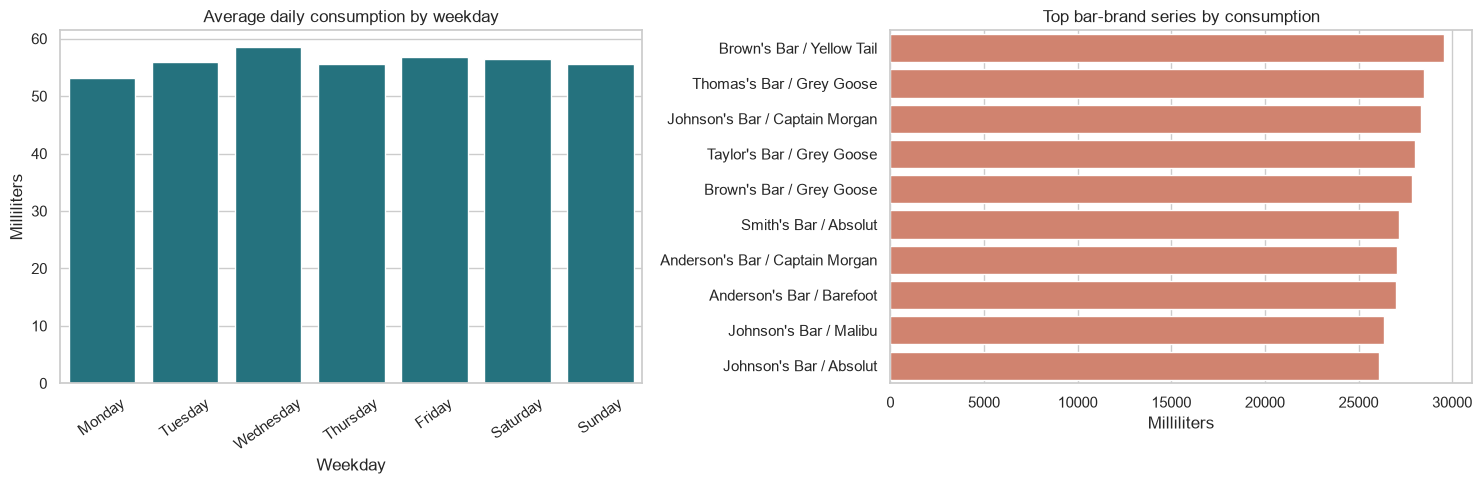

In [14]:
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
eda = daily_ts.copy()
eda['Weekday'] = eda['Date'].dt.day_name()
weekday = eda.groupby('Weekday')['Consumed (ml)'].mean().reindex(weekday_order)
top_series = (eda.groupby(['Bar Name', 'Brand Name'])['Consumed (ml)'].sum()
              .sort_values(ascending=False).head(10))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(x=weekday.index, y=weekday.values, color='#167d8d', ax=axes[0])
axes[0].set_title('Average daily consumption by weekday')
axes[0].set_ylabel('Milliliters')
axes[0].tick_params(axis='x', rotation=35)
sns.barplot(x=top_series.values, y=[f'{bar} / {brand}' for bar, brand in top_series.index], color='#e07a5f', ax=axes[1])
axes[1].set_title('Top bar-brand series by consumption')
axes[1].set_xlabel('Milliliters')
axes[1].set_ylabel('')
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'eda_overview.png', dpi=160, bbox_inches='tight')
plt.show()

In [15]:
annual = (daily_ts.groupby(['Bar Name', 'Brand Name'])['Consumed (ml)']
          .sum().sort_values(ascending=False))
abc_table = annual.rename('annual_consumption_ml').to_frame()
abc_table['cumulative_share'] = abc_table['annual_consumption_ml'].cumsum() / annual.sum()
abc_table['ABC_class'] = pd.cut(
    abc_table['cumulative_share'], bins=[0, 0.80, 0.95, 1.0],
    labels=['A', 'B', 'C'], include_lowest=True,
)
abc_table = abc_table.reset_index()
abc_table.to_csv(DATA_DIR / 'abc_inventory_segmentation.csv', index=False)
abc_table.head(10)

,Bar Name,Brand Name,annual_consumption_ml,cumulative_share,ABC_class
0,Brown's Bar,Yellow Tail,29588.63,0.015030,A
1,Thomas's Bar,Grey Goose,28510.30,0.029512,A
2,Johnson's Bar,Captain Morgan,28319.66,0.043897,A
3,Taylor's Bar,Grey Goose,28017.89,0.058128,A
4,Brown's Bar,Grey Goose,27873.30,0.072287,A
5,Smith's Bar,Absolut,27181.45,0.086094,A
6,Anderson's Bar,Captain Morgan,27066.83,0.099842,A
7,Anderson's Bar,Barefoot,26989.63,0.113552,A
8,Johnson's Bar,Malibu,26356.51,0.126940,A
9,Johnson's Bar,Absolut,26070.31,0.140182,A


## 3. Chronological forecasting and evaluation

In [5]:
model_df = daily_ts.copy()
grouped = model_df.groupby(['Bar Name', 'Brand Name'], sort=False)['Consumed (ml)']
for lag in [1, 7, 14]:
    model_df[f'lag_{lag}'] = grouped.shift(lag)
shifted = grouped.shift(1)
model_df['rolling_mean_7'] = shifted.transform(lambda values: values.rolling(7, min_periods=3).mean())
model_df['rolling_std_7'] = shifted.transform(lambda values: values.rolling(7, min_periods=3).std())
model_df['dayofweek'] = model_df['Date'].dt.dayofweek
model_df['is_weekend'] = model_df['dayofweek'].isin([5, 6]).astype(int)
model_df = model_df.dropna(subset=['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7']).copy()

feature_cols = ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'dayofweek', 'is_weekend', 'Bar Name', 'Brand Name']
categorical = ['Bar Name', 'Brand Name']
cutoff = model_df['Date'].min() + (model_df['Date'].max() - model_df['Date'].min()) * 0.8
train = model_df[model_df['Date'] < cutoff].copy()
test = model_df[model_df['Date'] >= cutoff].copy()

preprocess = ColumnTransformer([
    ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical),
], remainder='passthrough')
rf = Pipeline([
    ('preprocess', preprocess),
    ('model', RandomForestRegressor(n_estimators=60, min_samples_leaf=3, random_state=42, n_jobs=-1)),
])
rf.fit(train[feature_cols], train['Consumed (ml)'])
test['seasonal_naive_7'] = test['lag_7'].clip(lower=0)
test['random_forest'] = np.maximum(0, rf.predict(test[feature_cols]))
print(f'Train rows: {len(train):,} | Validation rows: {len(test):,} | Cutoff: {cutoff.date()}')

Train rows: 26,976 | Validation rows: 6,816 | Cutoff: 2023-10-22


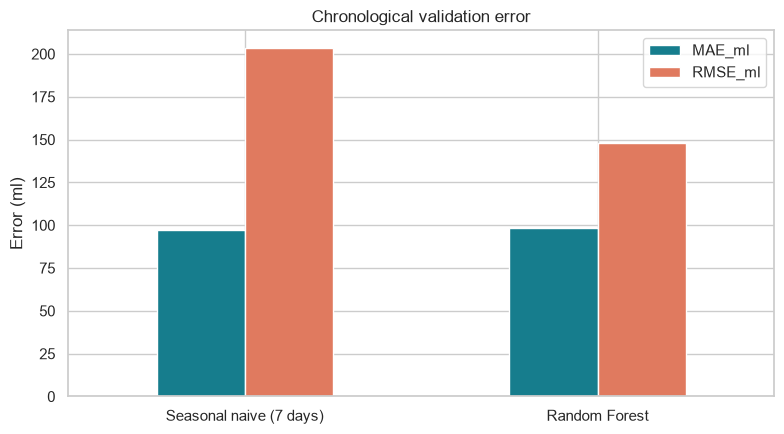

,MAE_ml,RMSE_ml,WAPE
Seasonal naive (7 days),97.4,203.5,175.0%
Random Forest,98.3,148.2,176.6%


In [6]:
def wape(actual, forecast):
    denominator = np.abs(actual).sum()
    return np.abs(actual - forecast).sum() / denominator if denominator else np.nan

metrics = pd.DataFrame({
    'MAE_ml': [
        mean_absolute_error(test['Consumed (ml)'], test['seasonal_naive_7']),
        mean_absolute_error(test['Consumed (ml)'], test['random_forest']),
    ],
    'RMSE_ml': [
        mean_squared_error(test['Consumed (ml)'], test['seasonal_naive_7']) ** 0.5,
        mean_squared_error(test['Consumed (ml)'], test['random_forest']) ** 0.5,
    ],
    'WAPE': [
        wape(test['Consumed (ml)'].to_numpy(), test['seasonal_naive_7'].to_numpy()),
        wape(test['Consumed (ml)'].to_numpy(), test['random_forest'].to_numpy()),
    ],
}, index=['Seasonal naive (7 days)', 'Random Forest'])
metrics.to_csv(DATA_DIR / 'forecast_metrics.csv')

fig, ax = plt.subplots(figsize=(8, 4.5))
metrics[['MAE_ml', 'RMSE_ml']].plot.bar(ax=ax, color=['#167d8d', '#e07a5f'])
ax.set_title('Chronological validation error')
ax.set_ylabel('Error (ml)')
ax.tick_params(axis='x', rotation=0)
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'forecast_model_comparison.png', dpi=160, bbox_inches='tight')
plt.show()
metrics.style.format({'MAE_ml': '{:,.1f}', 'RMSE_ml': '{:,.1f}', 'WAPE': '{:.1%}'})

## 4. Par-level recommendation and inventory-policy simulation

In [7]:
LEAD_TIME_DAYS = 2
SERVICE_LEVEL_Z = 1.645

def compute_par_level(predicted_daily_demand, std_daily_demand, lead_time_days=LEAD_TIME_DAYS, service_level_z=SERVICE_LEVEL_Z):
    lead_time_demand = max(0.0, float(predicted_daily_demand)) * lead_time_days
    safety_stock = service_level_z * max(0.0, float(std_daily_demand)) * np.sqrt(lead_time_days)
    return lead_time_demand + safety_stock, safety_stock

def simulate_inventory(actual_demand, par_level, lead_time_days=LEAD_TIME_DAYS):
    stock = float(par_level)
    pending = []
    stockout_days = 0
    lost_volume = 0.0
    history = []
    for demand in actual_demand:
        arriving = sum(quantity for days, quantity in pending if days <= 1)
        pending = [(days - 1, quantity) for days, quantity in pending if days > 1]
        stock += arriving
        fulfilled = min(stock, float(demand))
        lost = float(demand) - fulfilled
        stock -= fulfilled
        if lost > 0:
            stockout_days += 1
            lost_volume += lost
        inventory_position = stock + sum(quantity for _, quantity in pending)
        if inventory_position < par_level:
            pending.append((lead_time_days, par_level - inventory_position))
        history.append(stock)
    return {
        'stockout_days': stockout_days,
        'lost_volume_ml': lost_volume,
        'average_inventory_ml': float(np.mean(history)),
        'history': history,
    }

series_stats = (train.groupby(['Bar Name', 'Brand Name'])
                .agg(predicted_daily_demand=('lag_7', 'mean'), std_daily_demand=('Consumed (ml)', 'std'))
                .reset_index())
series_stats['std_daily_demand'] = series_stats['std_daily_demand'].fillna(0)
series_stats[['par_level_ml', 'safety_stock_ml']] = series_stats.apply(
    lambda row: pd.Series(compute_par_level(row['predicted_daily_demand'], row['std_daily_demand'])), axis=1)
series_stats.head()

,Bar Name,Brand Name,predicted_daily_demand,std_daily_demand,par_level_ml,safety_stock_ml
0,Anderson's Bar,Absolut,27.998292,92.823599,271.939669,215.943085
1,Anderson's Bar,Bacardi,75.658790,163.543313,531.781687,380.464107
2,Anderson's Bar,Barefoot,78.306797,166.711825,544.448868,387.835273
3,Anderson's Bar,Budweiser,35.808861,112.009339,332.194156,260.576433
4,Anderson's Bar,Captain Morgan,76.357794,171.166356,550.913799,398.198212


In [8]:
recommendation_rows = []
for keys, series in test.groupby(['Bar Name', 'Brand Name']):
    stat = series_stats[(series_stats['Bar Name'] == keys[0]) & (series_stats['Brand Name'] == keys[1])].iloc[0]
    result = simulate_inventory(series['Consumed (ml)'].to_numpy(), stat['par_level_ml'])
    recommendation_rows.append({
        'Bar Name': keys[0],
        'Brand Name': keys[1],
        'predicted_daily_demand_ml': stat['predicted_daily_demand'],
        'safety_stock_ml': stat['safety_stock_ml'],
        'par_level_ml': stat['par_level_ml'],
        'stockout_days': result['stockout_days'],
        'lost_volume_ml': result['lost_volume_ml'],
        'average_inventory_ml': result['average_inventory_ml'],
    })
recommendations = pd.DataFrame(recommendation_rows).sort_values('lost_volume_ml', ascending=False)
recommendations.to_csv(DATA_DIR / 'par_level_recommendations.csv', index=False)
print('Aggregate validation policy results:')
print(recommendations[['stockout_days', 'lost_volume_ml', 'average_inventory_ml']].sum().to_string())
recommendations.head(10)

Aggregate validation policy results:
stockout_days             418.000000
lost_volume_ml          68193.244011
average_inventory_ml    33579.461117


,Bar Name,Brand Name,predicted_daily_demand_ml,safety_stock_ml,par_level_ml,stockout_days,lost_volume_ml,average_inventory_ml
21,Brown's Bar,Coors,30.712456,265.251352,326.676263,5,2703.014949,271.531050
95,Thomas's Bar,Yellow Tail,37.090427,261.417749,335.598603,14,2399.876761,204.172597
74,Taylor's Bar,Jim Beam,61.755765,319.970372,443.481902,8,2169.928588,325.282875
42,Johnson's Bar,Jim Beam,38.245338,281.907608,358.398284,10,1828.672012,262.282848
78,Taylor's Bar,Sutter Home,38.506797,267.098327,344.111921,8,1775.386550,265.876613
22,Brown's Bar,Grey Goose,72.150712,374.116785,518.418209,7,1687.558956,394.666067
73,Taylor's Bar,Jameson,54.932028,314.193072,424.057129,9,1658.967228,329.111699
27,Brown's Bar,Malibu,46.249217,305.906555,398.404989,8,1570.165076,288.019709
77,Taylor's Bar,Smirnoff,57.861851,335.742412,451.466113,10,1438.851092,295.279947
31,Brown's Bar,Yellow Tail,79.199324,386.128264,544.526911,4,1388.452355,426.815428


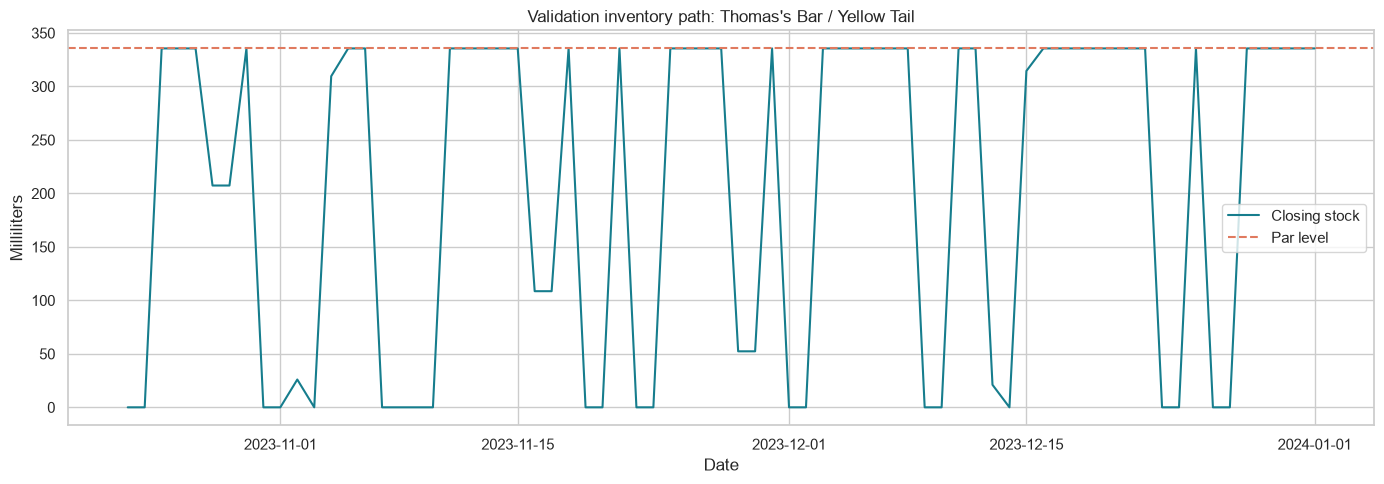

Report written to: d:\Nxtwave Projects\ML - Inventory Demand Forecasting and Par Level Recommendation System for Bars\report\business_report.md
PDF report written to: d:\Nxtwave Projects\ML - Inventory Demand Forecasting and Par Level Recommendation System for Bars\report\business_report.pdf
Selected policy: 14 stockout days, 2,400 ml lost volume


In [ ]:
selected = test.groupby(['Bar Name', 'Brand Name'])['Consumed (ml)'].sum().idxmax()
selected_test = test[(test['Bar Name'] == selected[0]) & (test['Brand Name'] == selected[1])].copy()
selected_stat = series_stats[(series_stats['Bar Name'] == selected[0]) & (series_stats['Brand Name'] == selected[1])].iloc[0]
selected_sim = simulate_inventory(selected_test['Consumed (ml)'].to_numpy(), selected_stat['par_level_ml'])

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(selected_test['Date'], selected_sim['history'], label='Closing stock', color='#167d8d')
ax.axhline(selected_stat['par_level_ml'], color='#e07a5f', linestyle='--', label='Par level')
ax.set_title(f'Validation inventory path: {selected[0]} / {selected[1]}')
ax.set_ylabel('Milliliters')
ax.set_xlabel('Date')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'inventory_policy_example.png', dpi=160, bbox_inches='tight')
plt.show()

# Write a portable business report from the same notebook run.
report_text = f'''# Bar Inventory Forecasting and Par-Level Recommendation

## Executive summary
This notebook cleans the original transaction-level Excel dataset, forecasts demand by bar and brand, evaluates a seasonal baseline against a Random Forest, and recommends inventory par levels for a two-day supplier lead time.

## Data and quality
- Source: `Consumption Dataset.xlsx`; transaction rows loaded: {quality['rows_loaded']:,}; completed daily rows: {len(daily_ts):,}.
- Scope: {daily_ts['Bar Name'].nunique()} bars, {daily_ts['Brand Name'].nunique()} brands, {len(pairs)} bar-brand series.
- Date range: {daily_ts['Date'].min().date()} to {daily_ts['Date'].max().date()}.
- Invalid dates: {quality['invalid_dates']}; invalid numeric rows: {quality['invalid_numeric_values']}; duplicate rows: {quality['duplicate_rows']}.
- Maximum absolute conservation error: {raw['conservation_error_ml'].abs().max():.8f} ml.

## Forecast evidence
The chronological 80/20 validation compares a seven-day seasonal-naive forecast with a Random Forest using lags, rolling statistics, weekday, weekend, bar, and brand features. The seasonal baseline WAPE is {metrics.loc['Seasonal naive (7 days)', 'WAPE']:.1%} and the Random Forest WAPE is {metrics.loc['Random Forest', 'WAPE']:.1%}. RMSE values are {metrics.loc['Seasonal naive (7 days)', 'RMSE_ml']:.1f} ml and {metrics.loc['Random Forest', 'RMSE_ml']:.1f} ml respectively.

## Inventory recommendation
Par level = predicted daily demand x {LEAD_TIME_DAYS} lead-time days + {SERVICE_LEVEL_Z} x daily demand standard deviation x sqrt({LEAD_TIME_DAYS}). The validation simulation produced {int(recommendations['stockout_days'].sum()):,} stockout days, {recommendations['lost_volume_ml'].sum():,.0f} ml lost volume, and {recommendations['average_inventory_ml'].sum():,.0f} ml summed average inventory across {len(recommendations)} series.

The highest-volume validation series was **{selected[0]} / {selected[1]}**, with {selected_sim['stockout_days']} stockout days and {selected_sim['lost_volume_ml']:,.0f} ml lost volume.

## Assumptions and next steps
Demand is measured in milliliters, unmet demand is treated as lost, lead time is constant, and observed consumption may be censored by historical stockouts. Add promotions, events, vendor lead-time variation, and a live inventory position before production deployment.
'''
(REPORT_DIR / 'business_report.md').write_text(report_text, encoding='utf-8')

with PdfPages(REPORT_DIR / 'business_report.pdf') as pdf:
    for figure_path in [FIGURE_DIR / 'eda_overview.png', FIGURE_DIR / 'forecast_model_comparison.png', FIGURE_DIR / 'inventory_policy_example.png']:
        image = plt.imread(figure_path)
        report_figure, report_ax = plt.subplots(figsize=(11, 7))
        report_ax.imshow(image)
        report_ax.axis('off')
        pdf.savefig(report_figure, bbox_inches='tight')
        plt.close(report_figure)

print(f'Report written to: {REPORT_DIR / "business_report.md"}')
print(f'PDF report written to: {REPORT_DIR / "business_report.pdf"}')
print(f'Selected policy: {selected_sim["stockout_days"]} stockout days, {selected_sim["lost_volume_ml"]:,.0f} ml lost volume')

## 5. Deliverables and operational interpretation

Running all cells creates:

- `data/processed/daily_bar_consumption.csv`: cleaned complete daily series.
- `data/processed/abc_inventory_segmentation.csv`: A/B/C inventory priorities.
- `data/processed/forecast_metrics.csv`: baseline and Random Forest validation metrics.
- `data/processed/par_level_recommendations.csv`: daily bar-brand reorder recommendations.
- `report/figures/`: EDA, model comparison, and inventory-policy figures.
- `report/business_report.md` and `report/business_report.pdf`: generated business report.

Use `par_level_recommendations.csv` as the manager review queue. Prioritize high lost-volume and stockout-risk series, verify supplier lead times, and monitor WAPE, stockouts, lost volume, holding inventory, and data quality after deployment.